# Module 2: Data Preprocessing and Feature Engineering  
This notebook transforms raw data into **predictive features**.  
The main focus is on applying **Cross-Sectional Ranking** to normalize data across different stocks at the same point in time.

> **Environment Note:** This notebook was developed and tested on a **Linux-based environment**. If you are running it on Windows, some file paths (e.g., `src/features.py`) may need to use backslashes, and shell commands prefixed with `!` may not work as expected. Consider using [WSL](https://learn.microsoft.com/en-us/windows/wsl/) or running it inside a Linux container for the smoothest experience.

In [1]:
%pip install pandas numpy matplotlib vnstock xgboost pyarrow scikit-learn optuna streamlit google-generativeai gplearn torch requests scipy
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import sklearn
import time
import os
import sys
import seaborn as sns

project_root = os.path.abspath("/kaggle/input/datasets/phmhuyphongp/modules-vn100")

if project_root not in sys.path:
    sys.path.append(project_root)

import src.features as ft
import src.evaluation as ev
import src.models as md 
import src.feature_search as fs
import src.alpha_mining as alpm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.4/277.4 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
Note: you may need to restart the kernel to use updated packages.


In [2]:

FILE_URL = "/kaggle/input/datasets/phmhuyphongp/vn100-dataset/market_data.parquet"
df_raw = pd.read_parquet(FILE_URL)
df_raw.head()

,date,open,high,low,close,volume,Symbol
0,2018-08-24,12.74,12.92,12.66,12.92,1174270,AAA
1,2018-08-27,12.92,13.00,12.77,12.81,1457700,AAA
2,2018-08-28,12.89,12.92,12.70,12.74,949300,AAA
3,2018-08-29,12.85,13.08,12.66,13.08,2076640,AAA
4,2018-08-30,13.11,13.72,13.11,13.64,3814460,AAA


## 2.1 Feature Selection Rationale
In this project, I select 8 primary features categorized into three groups to capture the Vietnamese stock market's dynamics:

* **Momentum Indicators**: `log_ret_1m`, `log_ret_3m`, `log_ret_1y` - These capture the trend-following behavior of investors.
* **Risk & Volatility**: `volatility_3m`, `volatility_shock_monthly` - These measure the systematic and unsystematic risk levels.
* **Trend & Liquidity**: `dist_SMA_100`, `RSI_14`, `volume_surge_monthly` - These identify overbought/oversold conditions and abnormal trading interest.

### Cross-Sectional Ranking
Instead of using absolute values, I apply **Cross-Sectional Ranking** to every feature. This technique normalizes data across 100 tickers at each timestamp, effectively removing "Market Beta" and focusing on the relative strength (Alpha) of each stock within the VN100 basket.

In [3]:
# Define your features and target
features = [
    'log_ret_1m', 'log_ret_3m', 'log_ret_1y',
    'volatility_shock_monthly', 'volatility_3m',
    'dist_SMA_100', 'RSI_14', 'volume_surge_monthly'
]


In [4]:
wq = alpm.WorldQuantAlphas(df_raw)
wq_cols_df = wq.generate_all()
df_raw[wq_cols_df.columns] = wq_cols_df.values
df = ft.build_features(df_raw)
df = ft.target_generating_ranking(df)
#df,new_features = ft.apply_cross_sectional_ranking(df,features)
#features = features + new_features

Generating WorldQuant Alphas...


/kaggle/input/datasets/phmhuyphongp/modules-vn100/src/features.py:94: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['obv_trend'] = (grouped.apply(


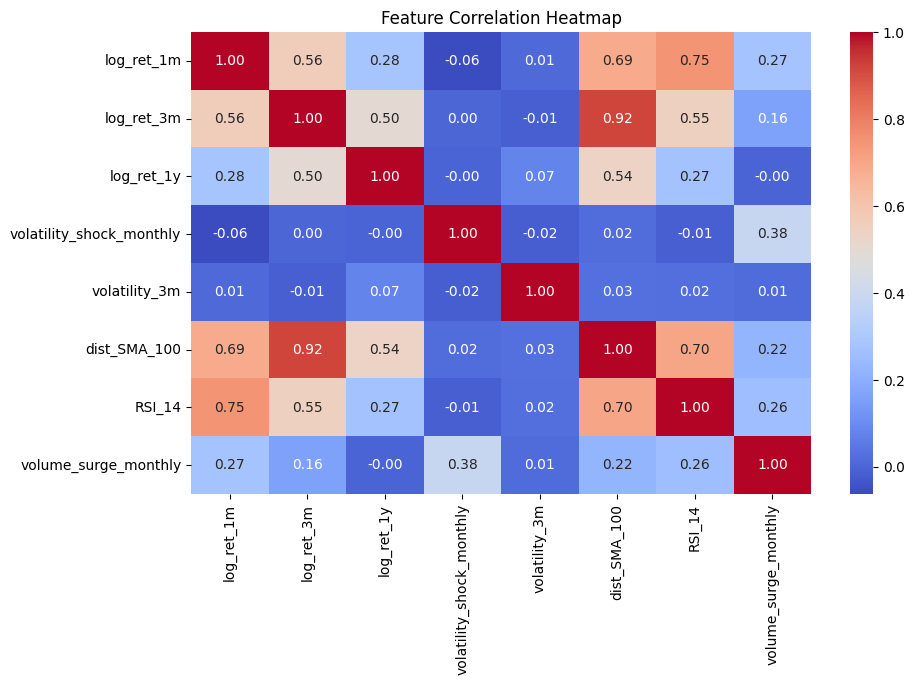

In [5]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [6]:
best_roi_row, best_sharpe_row, result_df = fs.search_best_roi_and_sharpe(
    df,
    initial_capital=10_000,
    walk_forward_kwargs=dict(initial_train_months=24, test_months=6, gap_days=21),
    backtest_kwargs=dict(buy_fraction=0.05, hold_fraction=0.15,
                         trend_filter_col='dist_SMA_100'),
)

[1/127] Testing: returns
Fold 1/9 (2021-08): NDCG = 0.8146
Fold 2/9 (2022-02): NDCG = 0.8389
Fold 3/9 (2022-08): NDCG = 0.8273
Fold 4/9 (2023-02): NDCG = 0.8369
Fold 5/9 (2023-08): NDCG = 0.8266
Fold 6/9 (2024-02): NDCG = 0.8328
Fold 7/9 (2024-08): NDCG = 0.8249
Fold 8/9 (2025-02): NDCG = 0.8486
Fold 9/9 (2025-08): NDCG = 0.8106
Fold 10/9 (2026-02): NDCG = 0.7589

✅ Walk-forward CV complete.
         >> Result: ROI =    34.52% | Sharpe =   0.19
         🏆 Current Leader (First Run)
[2/127] Testing: volatility
Fold 1/9 (2021-08): NDCG = 0.8200
Fold 2/9 (2022-02): NDCG = 0.8396
Fold 3/9 (2022-08): NDCG = 0.8333
Fold 4/9 (2023-02): NDCG = 0.8278
Fold 5/9 (2023-08): NDCG = 0.8362
Fold 6/9 (2024-02): NDCG = 0.8391
Fold 7/9 (2024-08): NDCG = 0.8325
Fold 8/9 (2025-02): NDCG = 0.8147
Fold 9/9 (2025-08): NDCG = 0.8371
Fold 10/9 (2026-02): NDCG = 0.8088

✅ Walk-forward CV complete.
         >> Result: ROI =    19.60% | Sharpe =   0.06
[3/127] Testing: moving_average
Fold 1/9 (2021-08): NDCG = 0.